In [2]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
tqdm.pandas()
#
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#### Load data

In [125]:
# Load in data
data_frame2seq = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/data/conf-bias-output/5KPE-5KPH/designs_conf-bias_frame2seq.csv',
    index_col=0
)
data_proteinmpnn = pd.read_csv(
    '/wynton/home/rotation/geanhu/multi-state/data/conf-bias-output/5KPE-5KPH/designs_conf-bias_proteinmpnn.csv',
    index_col=0
)
data = pd.merge(
    data_frame2seq, data_proteinmpnn,
    on=['name', 'mut'],
    how='left',
    validate='one_to_one'
)

# Separate parameters and sample naming
data['parameters'] = data['name'].apply(
    lambda name : name.split('_5KP')[0], # param
)
data['name'] = data['name'].apply(
    lambda name: f'5KP{name.split("_5KP")[1]}'# name
)

In [126]:
designs = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv')
designs = designs[['parameters', 'id']].reset_index(names='design')
data = data.merge(
    designs,
    how='left',
    left_on=[
        'parameters', 'name'
    ],
    right_on=[
        'parameters',
        'id'
    ],
    validate='many_to_one'
).drop(columns='id')

#### Prepare data

In [127]:
# filter for data of interest
structure = '5KPH'
rmsd = 2
#
graph_df = data[
    #(data['name'].str.contains(f'{structure}_{rmsd}'))
    (~(data['mut'] == 'wt'))
]

In [128]:
# z-score
def z_score(
    df: pd.DataFrame,
    state_cols: list[str]
):
    for col in state_cols:
        df[f'{col}_z'] = (df[col] - df[col].mean()) / df[col].std()
    return df

# bias
def bias(
    df: pd.DataFrame,
    state_cols: list[str]
):
    assert len(state_cols) == 2
    #
    for idx in range(2):
        df[f'{state_cols[idx]}_bias'] = (
            df[state_cols[idx]] - df[state_cols[1 - idx]]
        )
    #
    return df

models = ['frame2seq', 'proteinmpnn']
for model in models:
    # normalize
    graph_df = z_score(
        graph_df,
        [f'{model}_pdb0', f'{model}_pdb1']
    )

    # transformed -> bias
    graph_df = bias(
        graph_df,
        [f'{model}_pdb0_z', f'{model}_pdb1_z']
    )

    # untransformed -> bias
    graph_df = bias(
        graph_df,
        [f'{model}_pdb0', f'{model}_pdb1']
    )

# combine bias
graph_df['combined_bias'] = graph_df[['frame2seq_pdb0_z_bias', 'proteinmpnn_pdb0_z_bias']].mean(axis=1)


#### Plot

Plotting ...


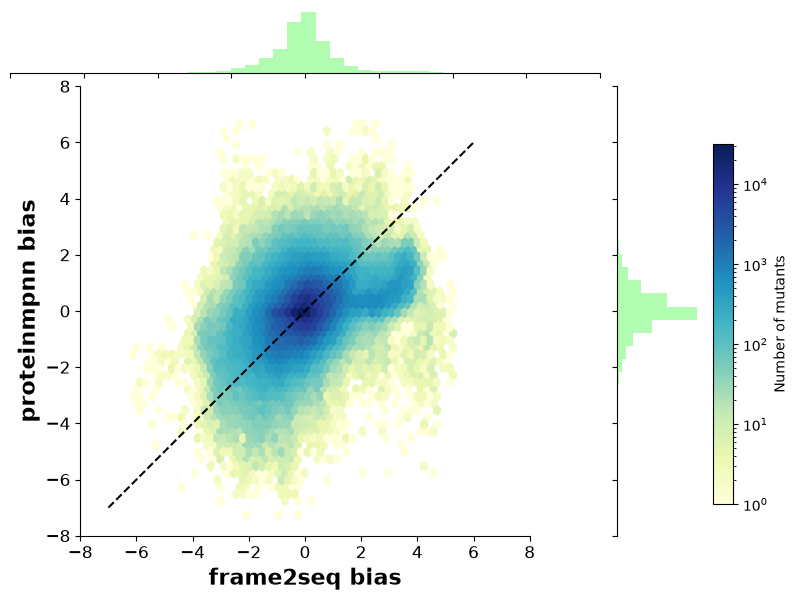

In [ ]:
# compare scores

# sort by combined (summed) bias ~= agreement
graph_df['combined_bias'] = graph_df['proteinmpnn_pdb0_z_bias'] + graph_df['frame2seq_pdb0_z_bias']
graph_df = graph_df.sort_values(
    by='combined_bias', ascending=False
).reset_index(drop=True)

# assign bias
if 'bias' not in graph_df.columns:
    model = 'proteinmpnn' # with proteinmpnn scores, for now
    graph_df['bias'] = graph_df.progress_apply(
        # use proteinmpnn to filter out low expresssion mutants, for now
        lambda row: assign_bias(row, len(graph_df), 'proteinmpnn'), axis=1
    ) #type: ignore
    graph_df['bias'] = graph_df['bias'].astype('category')

# plot
print('Plotting ...')
x = 'frame2seq_pdb0_z_bias'
y = 'proteinmpnn_pdb0_z_bias'

graph = sns.JointGrid(
    data=graph_df,
    x = x,
    y = y,
    height=6,
    ratio=6
)

# hexbin instead of scatter
hb = graph.ax_joint.hexbin(
    graph_df[x],
    graph_df[y],
    gridsize=50,
    mincnt=1,
    cmap='YlGnBu',
    bins='log'
)

# marginal distributions
sns.histplot(
    data=graph_df,
    x=x,
    ax=graph.ax_marg_x,
    bins=30,
    color='palegreen',
    linewidth=0
)
sns.histplot(
    data=graph_df,
    y=y,
    ax=graph.ax_marg_y,
    bins=30,
    color='palegreen',
    linewidth=0
)

# plot y = x
graph.ax_joint.plot(
    np.arange(-7, 7),
    np.arange(-7, 7),
    color = 'black',
    linestyle='--',
    label='y=x'
)

# axes
ax = graph.ax_joint
ax.set_xlabel('frame2seq bias', fontsize=16, fontweight='bold')
ax.set_ylabel('proteinmpnn bias', fontsize=16, fontweight='bold')
ax.tick_params(
    axis='both',
    labelsize=12,
)

# set square axes
ax.set_xlim(
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[-1], ax.get_ylim()[-1])
)
ax.set_ylim(ax.get_xlim())
ax.set_aspect('equal')

# colorbar
graph.figure.set_size_inches(8, 6)
cax = graph.figure.add_axes([
    0.99, 0.15, 0.025, 0.6
]) #type: ignore
cbar = graph.figure.colorbar(
    hb,
    cax=cax
) 
cbar.set_label('Number of mutants')

#
plt.show()

In [88]:
# separate by structure
#designs = np.unique(graph_df['design'])
designs = [0, 20, 233, 417]

graph_dfs = [
    graph_df[graph_df['design'] == design]
    for design in designs
]

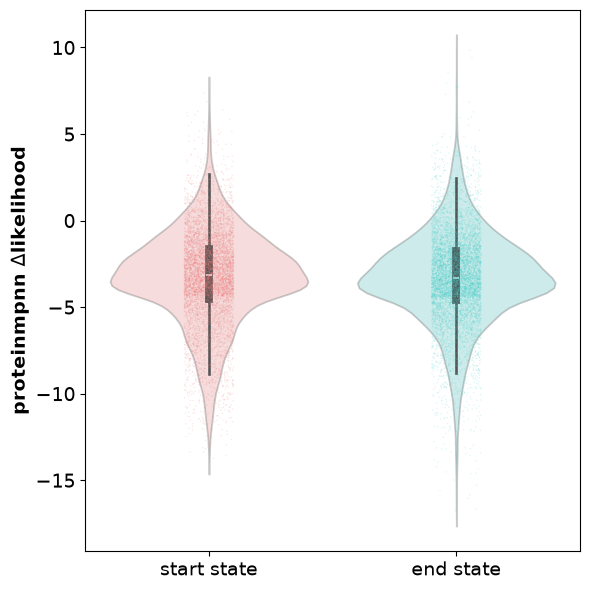

In [9]:
# distributions of raw scores for each state
fig, ax = plt.subplots(figsize=(6, 6))

model = 'proteinmpnn'
graph_df_safe = graph_df.copy()
graph_df = graph_df[
    (graph_df[f'{model}_pdb1_z'] > 0) | 
    (graph_df[f'{model}_pdb0_z'] > 0)
]

# plot 
sns.violinplot(
    data=graph_df[[
        f'{model}_pdb1',
        f'{model}_pdb0'
    ]],
    palette=[
        'lightcoral',
        'mediumturquoise'
    ],
    alpha = 0.3,
    zorder = -1
)
#
sns.stripplot(
    data=graph_df[[
        f'{model}_pdb1',
        f'{model}_pdb0'
    ]],
    palette=[
        'lightcoral',
        'mediumturquoise'
    ],
    size = 1,
    alpha = 0.2,
    ax=ax
)

# axes
ax.set_xticks([0, 1])
ax.set_xticklabels([
    'start state',
    'end state'
])
ax.set_xlabel(f'', fontsize=16, fontweight='bold')
ax.set_ylabel(rf'{model} $\Delta$likelihood', fontsize=14, fontweight='bold')
ax.tick_params(
    axis='both',
    labelsize=14,
)
plt.tight_layout()
plt.show()

graph_df = graph_df_safe.copy()

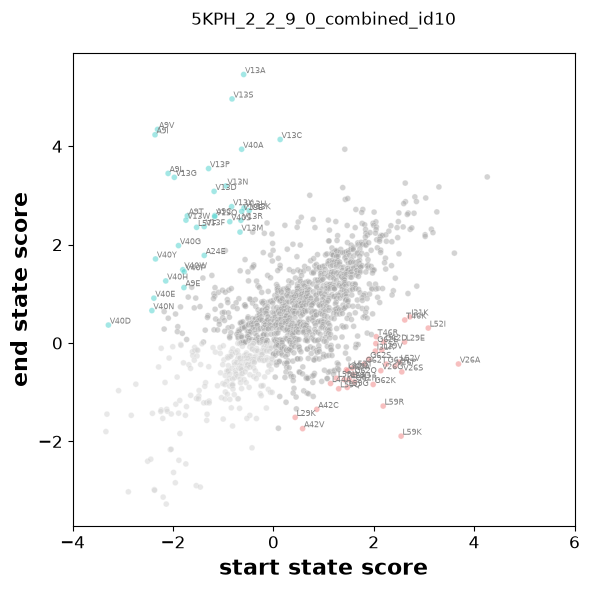

KeyboardInterrupt: 

In [ ]:
# plot bias for each state (transformed)
def assign_bias(row, total, model):
    # for bias assignment
    frac_mutants = 0.05
    n_biased = round((frac_mutants / 2) * total)

    # get scores
    end = row[f'{model}_pdb0_z']
    start = row[f'{model}_pdb1_z']

    # low := z-score < 0 for both
    if (end < 0 and start < 0):
        return 'low'
    else:
        # end bias
        if row.name < n_biased:
            return 'end'
        # neutral
        elif row.name < (total - n_biased):
            return 'neutral'
        # start bias
        else:
            return 'start'

for df in graph_dfs:
    # sort by bias to end state
    df = df.sort_values(
        f'{model}_pdb0_z_bias', ascending=False
    ).reset_index(drop=True) #biases are symmetrical, can sort with either

    # designate assignments
    if 'bias' not in df.columns:
        df['bias'] = df.apply(
            lambda row: assign_bias(row, len(df), model), axis=1
        )
        df['bias'] = df['bias'].astype('category')

    # figure
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=df,
        x = f'{model}_pdb1_z',
        y = f'{model}_pdb0_z',
        hue = 'bias',
        size = 1,
        alpha = 0.5,
        ax = ax,
        palette = {
            'low': 'lightgray',
            'neutral': 'darkgray',
            'start': 'lightcoral',
            'end': 'mediumturquoise'
        },
        legend=False
    )

    # annotate biased mutants
    for _, row in df[df['bias'].isin(['start', 'end'])].iterrows():
        ax.annotate(
            row['mut'],
            (row[f'{model}_pdb1_z'], row[f'{model}_pdb0_z']),
            xytext=(1, 1),
            textcoords='offset points',
            size='xx-small',
            color='grey'
        )
    
    # axes
    ax.set_xlabel('start state score', fontsize=16, fontweight='bold')
    ax.set_ylabel('end state score', fontsize=16, fontweight='bold')
    ax.tick_params(
        axis='both',
        labelsize=12,
    )
    ax.set_xlim(
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[-1], ax.get_ylim()[-1])
    )
    ax.set_ylim(ax.get_xlim())
    ax.set_xticks(ax.get_yticks())
    ax.set_title(f'{df.loc[0, 'name']}\n')
    plt.tight_layout()
    plt.show()

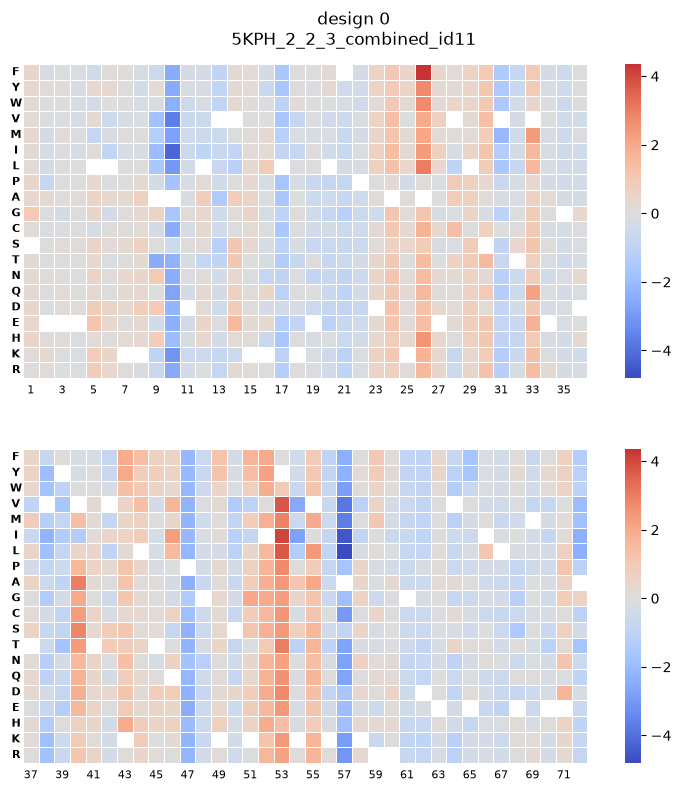

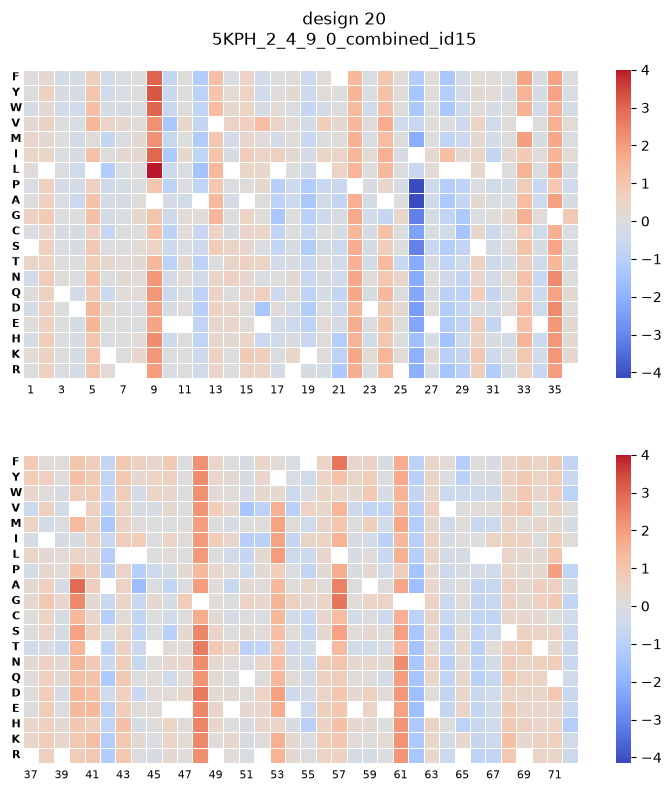

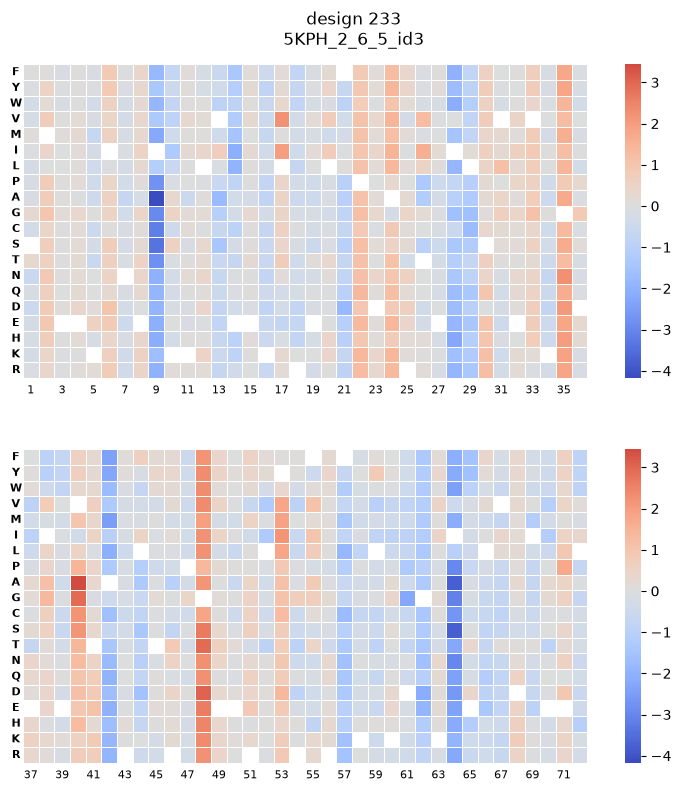

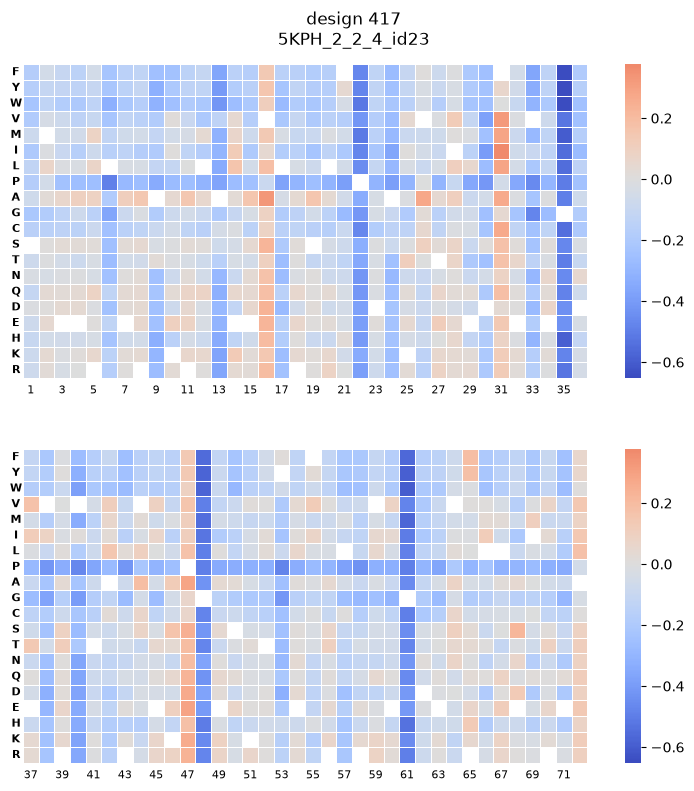

In [93]:
# see all mutants
for df in graph_dfs:
    # get mut idx (x-axis) and mutated to (y-axis) 
    df['mut_idx'] = df['mut'].apply(lambda mut: int(mut[1:-1]))
    df['mut_new'] = df['mut'].apply(lambda mut: mut[-1])

    # pivot df
    heatmap = df.pivot(
        index = 'mut_new', #y-axis
        columns = 'mut_idx', #x-axis
        values = 'combined_bias' #color
    )

    # sort columns in sequence order
    seq_order = np.argsort([int(idx) for idx in heatmap.columns])
    heatmap = heatmap.iloc[:, seq_order]

    # sort rows by AA character
    aa_order = list('FYWVMILPAGCSTNQDEHKR') #by chem character
    heatmap = heatmap.loc[aa_order]

    # split df
    split_num = 2
    mid = int(np.ceil(heatmap.shape[1] / split_num))
    heatmaps = [
        heatmap.iloc[:, (i * mid): ((i + 1) * mid)]
        for i in range(split_num)
    ]

    # same color map for all
    cmap = 'coolwarm'
    vmin = heatmap.min().min()
    vmax = heatmap.max().max()
    center = 0

    # plot
    fig, axes = plt.subplots(
        split_num, 1,
        figsize=(4*split_num, 4*split_num)
    )
    for i in range(split_num):

        ax = axes[i]
        # heatmap
        sns.heatmap(
            heatmaps[i],
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            center=center,
            yticklabels=aa_order,
            xticklabels=[
                str(num) if (num%2==1) else ''
                for num in range(heatmaps[i].columns[0], heatmaps[i].columns[-1] + 1)
            ],
            square=True,
            linewidths=0.5,
            linecolor='white',
            cmap=cmap
        )

        # axes
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.tick_params(
            axis='both',
            labelsize=8,
            labelrotation=0, # turn correct way
            length=0, #ticks off
            pad=5,
        )
        plt.setp(
            ax.get_yticklabels(),
            ha='center',
            fontweight='bold'
        )

        # title
        plt.suptitle(
            f'design {df.iloc[0]['design']}\n{df.iloc[0]['name']}'
        )

    plt.tight_layout(h_pad=4.0)
    plt.show()

##### non-normalized

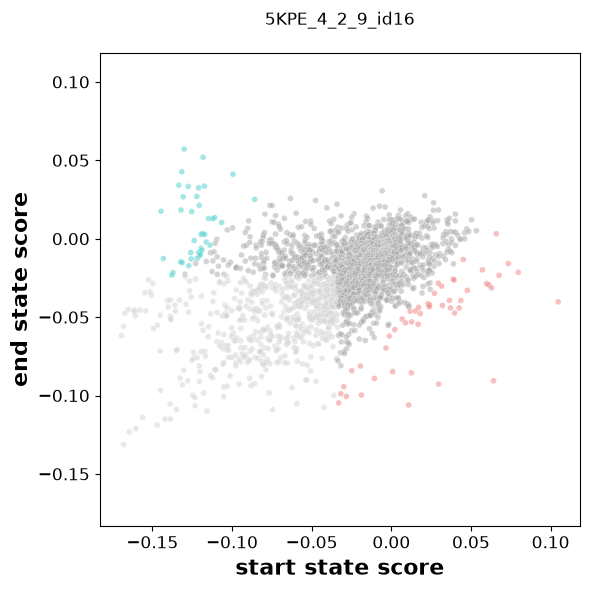

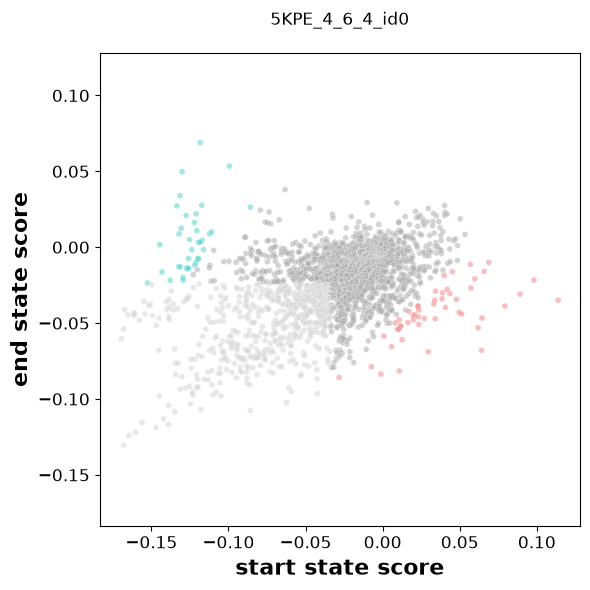

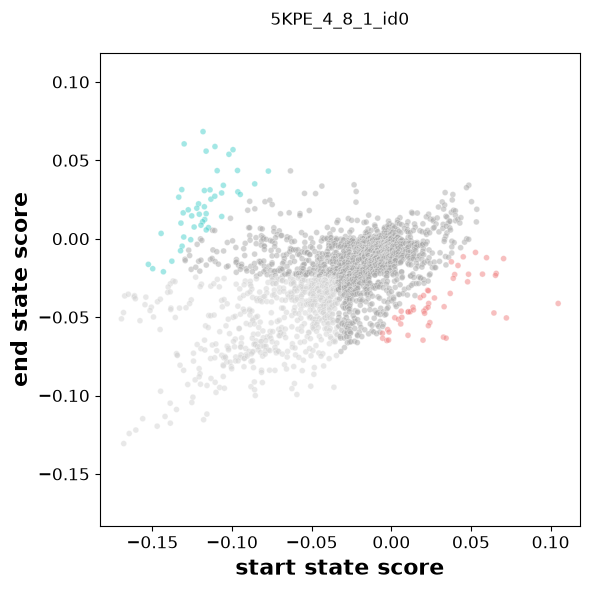

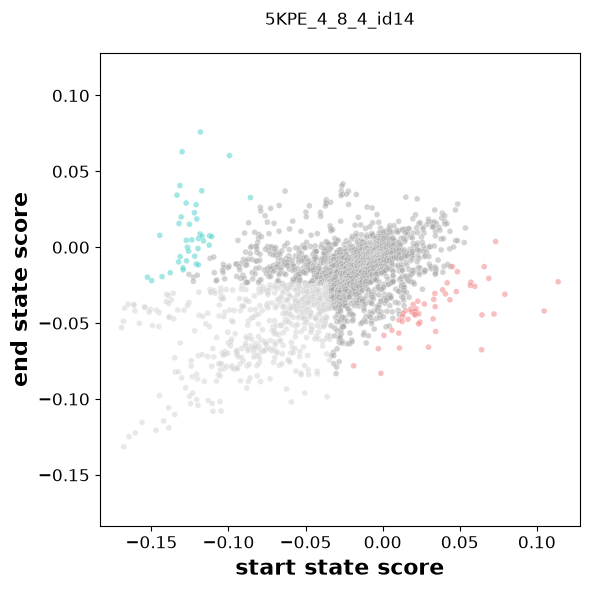

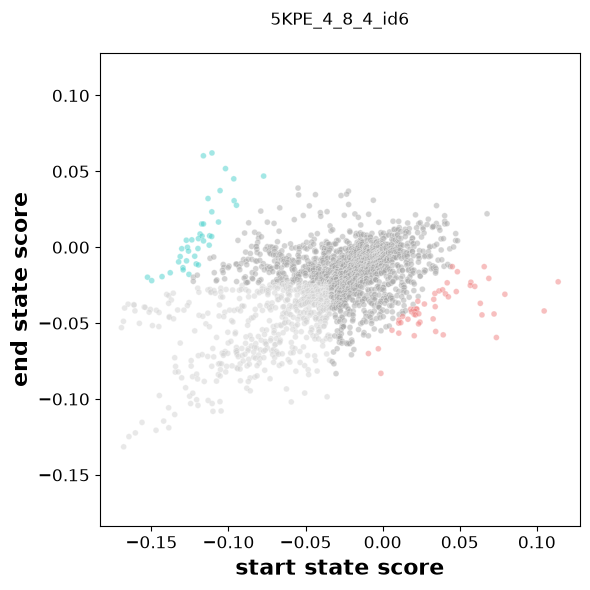

In [ ]:
# plot bias for each state (untransformed)
for df in graph_dfs:
    # sort by bias to end state
    df = df.sort_values(
        f'{model}_pdb0_bias', ascending=False
    ).reset_index(drop=True) #biases are symmetrical, can sort with either

    # designate assignments
    if 'bias' not in df.columns:
        df['bias'] = df.apply(
            lambda row: assign_bias(row, len(df)), axis=1
        )
        df['bias'] = df['bias'].astype('category')

    # figure
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=df,
        x = f'{model}_pdb1',
        y = f'{model}_pdb0',
        hue = 'bias',
        size = 1,
        alpha = 0.5,
        ax = ax,
        palette = {
            'low': 'lightgray',
            'neutral': 'darkgray',
            'start': 'lightcoral',
            'end': 'mediumturquoise'
        },
        legend=False
    )

    for _, row in df[df['bias'].isin(['start', 'end'])].iterrows():
        ax.annotate(
            row['mut'],
            (row[f'{model}_pdb1_z'], row[f'{model}_pdb0_z']),
            xytext=(1, 1),
            textcoords='offset points',
            size='xx-small',
            color='grey'
        )
    
    # axes
    ax.set_xlabel('start state score', fontsize=16, fontweight='bold')
    ax.set_ylabel('end state score', fontsize=16, fontweight='bold')
    ax.tick_params(
        axis='both',
        labelsize=12,
    )
    ax.set_ylim(ax.get_xlim())
    #ax.set_xticks(ax.get_yticks())
    ax.set_title(f'{df.loc[0, 'name']}\n')
    plt.tight_layout()
    plt.show()

#### Top mutants

In [97]:
# top ranked mutants -> start state
df = graph_df
df = df.sort_values(by=f'combined_bias')
num = 100
#
start = df.head(num)
start_names = np.unique(start['design'])
#
end = df.tail(num)
end_names = np.unique(end['design'])
#
names = set(start_names) & set(end_names)

In [118]:
# get 2A designs, top 5 mutants
save_df_list = []
for name in names:
    name_df = df[df['design'] == name]
    name_df = name_df.sort_values(by='combined_bias')
    #
    start = name_df.head(5)
    start['bias'] = 'start'
    save_df_list.append(
        start
    )
    #
    end = name_df.tail(5)
    end['bias'] = 'end'
    save_df_list.append(
        end
    )

save_df = pd.concat(save_df_list)

In [133]:
# get 4A designs, top 10 mutants
save_df_list = []

# all the 4A designs
for design in np.unique(
    data[
        data['name'].apply(
            lambda name: (
                ('5KPE_4_' in name) or
                ('5KPH_4_' in name)
            )
        )
    ]['design']
):
    name_df = graph_df[graph_df['design'] == design]
    name_df = name_df.sort_values(by='combined_bias')
    #
    start = name_df.head(10)
    start['bias'] = 'start'
    save_df_list.append(
        start
    )
    #
    end = name_df.tail(10)
    end['bias'] = 'end'
    save_df_list.append(
        end
    )

save_df = pd.concat(save_df_list)

In [135]:
# get sequence and save for AF input
design_df = pd.read_csv('/wynton/home/rotation/geanhu/multi-state/notebooks/data/designs/designs.csv', index_col=0)
af_input = {
    'id': [],
    'seq': []
}

for idx, row in save_df.iterrows(): #type: ignore
    # name
    af_input['id'].append(
        f'design-{row['design']}_mut-{row['mut']}_bias-{row['bias']}'
    )

    # original seq
    seq = design_df.iloc[row['design']]['sequence'] #type: ignore

    # mutate
    mut = row['mut']
    mut_o = mut[0]
    mut_idx = int(mut[1:-1])
    mut_n = mut[-1]
    seq = seq[:mut_idx - 1] + mut_n + seq[mut_idx:]

    # save
    af_input['seq'].append(seq)

# create df and save
af_input = pd.DataFrame(af_input)
af_input.to_csv(
    '/wynton/home/rotation/geanhu/multi-state/notebooks/data/mutants/5KPE-5KPH_4a.csv',
    index=False
)